In [23]:
import pandas as pd
from matplotlib.figure import Figure

df = pd.read_csv("../src_data/removed_data_cross_dedup.csv")
df

,runname,seed,steps,agg_score,commonsense_qa/acc,commonsense_qa/acc_norm,hellaswag/acc,hellaswag/acc_norm,openbookqa/acc,openbookqa/acc_norm,...,siqa/acc,siqa/acc_norm,winogrande/acc,winogrande/acc_norm,sciq/acc,sciq/acc_norm,arc/acc,arc/acc_norm,mmlu/acc,mmlu/acc_norm
0,deduped_removed_cross,5,0,0.330893,0.186,0.233,0.272,0.258,0.166,0.286,...,0.367,0.362,0.516,0.497,0.208,0.202,0.2195,0.2510,0.230294,0.250147
1,deduped_removed_cross,5,1000,0.354090,0.253,0.257,0.290,0.278,0.124,0.264,...,0.368,0.389,0.509,0.491,0.582,0.516,0.2825,0.2955,0.239520,0.253223
2,deduped_removed_cross,5,2000,0.373601,0.274,0.290,0.313,0.312,0.116,0.258,...,0.367,0.397,0.516,0.505,0.686,0.582,0.3090,0.3200,0.247320,0.262812
3,deduped_removed_cross,5,3000,0.383122,0.306,0.292,0.323,0.335,0.150,0.278,...,0.371,0.401,0.513,0.500,0.712,0.611,0.3075,0.3415,0.248568,0.263474
4,deduped_removed_cross,5,4000,0.390222,0.300,0.292,0.324,0.351,0.144,0.278,...,0.386,0.395,0.511,0.511,0.750,0.658,0.3260,0.3445,0.259246,0.273276
5,deduped_removed_cross,5,5000,0.400239,0.322,0.308,0.325,0.364,0.172,0.298,...,0.382,0.398,0.518,0.522,0.751,0.661,0.3470,0.3545,0.258485,0.271414
6,deduped_removed_cross,5,6000,0.401484,0.315,0.314,0.341,0.372,0.162,0.314,...,0.377,0.390,0.498,0.492,0.776,0.669,0.3530,0.3565,0.261842,0.276371
7,deduped_removed_cross,5,7000,0.403533,0.324,0.315,0.350,0.386,0.188,0.298,...,0.376,0.384,0.518,0.521,0.769,0.672,0.3625,0.3585,0.265558,0.274768
8,deduped_removed_cross,5,8000,0.411774,0.344,0.313,0.352,0.409,0.170,0.310,...,0.374,0.391,0.530,0.521,0.781,0.677,0.3530,0.3615,0.267141,0.283691
9,deduped_removed_cross,5,9000,0.410993,0.335,0.322,0.361,0.404,0.182,0.294,...,0.374,0.391,0.526,0.514,0.769,0.672,0.3630,0.3715,0.266464,0.284446


In [24]:
runs_mapping = {
    "deduped_removed_cross": "Originally removed data",
    "cross_minhash_dump_CC-MAIN-2013-48": "Originally kept data",
}

In [25]:
df.columns

Index(['runname', 'seed', 'steps', 'agg_score', 'commonsense_qa/acc',
       'commonsense_qa/acc_norm', 'hellaswag/acc', 'hellaswag/acc_norm',
       'openbookqa/acc', 'openbookqa/acc_norm', 'piqa/acc', 'piqa/acc_norm',
       'siqa/acc', 'siqa/acc_norm', 'winogrande/acc', 'winogrande/acc_norm',
       'sciq/acc', 'sciq/acc_norm', 'arc/acc', 'arc/acc_norm', 'mmlu/acc',
       'mmlu/acc_norm'],
      dtype='object')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


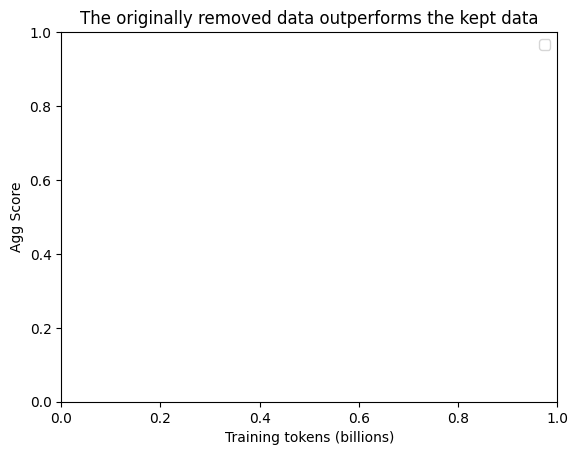

In [27]:
import json
import os
from matplotlib import pyplot as plt
metrics = ['agg_score', 'commonsense_qa/acc_norm', 'hellaswag/acc_norm', 'openbookqa/acc_norm', 'piqa/acc_norm',
                   'siqa/acc_norm', 'winogrande/acc_norm', 'arc/acc_norm', 'mmlu/acc_norm']

def normalize_runname(runname):
    return runname.replace("/", "_")

grouped = (
    df.groupby(["runname", "steps"])
    .agg(
        {
            key: "mean" for key in metrics
        }
    )
    .reset_index()
)

file_id="../assets/data/plots/removed_data_dedup"
files = {}
for metric in metrics:
    datas = {}
    for name, group in grouped.groupby("runname"):
        group = group[["steps", metric]].sort_values(by="steps")
        group = group.set_index("steps")
        rolling_avg = group
        # rolling_avg = group.rolling(window=5).mean()
        datas[name] = {
            "x": (rolling_avg.index * 2048 * 1024 * 1e-9).tolist(),
            "y": rolling_avg[metric].tolist(),
            "label": runs_mapping[name],
        }
    # Sort the datata based on the steps
    datas = {k: v for k, v in sorted(datas.items(), key=lambda x: -x[1]["y"][-1])}
    # Create a folder
    os.makedirs(f"{file_id}", exist_ok=True)
    with open(f"{file_id}/{normalize_runname(metric)}.json", "w") as f:
        json.dump({
            "data": datas,
            "layout": {
                "title": {
                    "text": "The originally removed data outperforms the kept data"
                },
            }
        }, f)
    files[metric] = {"file": f"{normalize_runname(metric)}.json"}
# Create index
with open(f"{file_id}/index.json", "w") as f:
    json.dump({
        "files": files,
        "settings": {
            "defaultMetric": "agg_score",
            "slider":{"min":0,"max":10,"default":0}
        }
    }, f)
        

# Add labels and legend
plt.xlabel("Training tokens (billions)")
plt.ylabel("Agg Score")
plt.title("The originally removed data outperforms the kept data")
plt.legend()

# Show the plot
plt.show()